In this notebook we perform different tests in order to make feature selection on the merged dataset

In [1]:
import pandas as pd
from merge_and_agregation import *
import warnings
from sklearn.ensemble import RandomForestClassifier

from feature_engine.selection import (
    DropCorrelatedFeatures,
    SmartCorrelatedSelection,
    SelectByShuffling,
    SelectBySingleFeaturePerformance,
    RecursiveFeatureElimination,
)

warnings.filterwarnings("ignore")

In [2]:
#Load, agregate, clean and merge the files
df_portefeuille=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_reclamations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_consommations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")

df_merged=create_clean_aggregated_dataset(df_consommations=df_consommations, df_impayes=df_impayes, df_reclamations=df_reclamations, df_portefeuille=df_portefeuille, df_interactions=df_interactions)

### Features selection

In [5]:
#Let's first quickly visualise the correlated features in the merged dataset
#Criterion: the pearson coefficient
correlated = DropCorrelatedFeatures(variables=None, method='pearson', threshold=0.8)
correlated.fit(df_merged)
correlated.correlated_feature_dict_

{'client_anciennete_contrat_annees': {'client_code'},
 'client_code_postal': {'client_departement'},
 'client_cotisations_annualisees_n': {'client_cotisations_annualisees_n_moins1',
  'client_cotisations_annualisees_n_moins2',
  'client_cotisations_annualisees_n_plus1'},
 'client_nb_assures_contrat': {'client_nb_enfants'},
 'courtier_nb_affaires_n_moins1': {'courtier_nb_affaires_n_moins2',
  'courtier_nb_radiations_n_moins1',
  'courtier_nb_radiations_n_moins2'},
 'frais_reels': {'frais_reels_soins_medicaux',
  'reste_a_charge',
  'reste_a_charge_soins_medicaux'},
 'frais_reels_dentaire': {'nb_protheses_dentaires',
  'remb_alptis_dentaire',
  'remb_ro_dentaire'},
 'frais_reels_divers': {'remb_alptis_divers', 'remb_ro_divers'},
 'frais_reels_hospitalisation': {'remb_alptis_hospitalisation',
  'remb_ro',
  'remb_ro_hospitalisation'},
 'frais_reels_optique': {'nb_decomptes_optique',
  'remb_alptis_optique',
  'reste_a_charge_optique'},
 'frais_reels_pharmacie': {'remb_alptis_pharmacie', '

This analysis validates some of our previous hypothesis, including that the number of members in the contract directly depends on the familial situation. 


In [6]:
#Let's select the best features in each group of correlated features using RandomForest
#To identify the group of correlated features we use the Pearson coefficient again

X_train= df_merged.drop(columns="target_resiliation_6mois")
y_train= df_merged["target_resiliation_6mois"]

smart_corr = SmartCorrelatedSelection( 
    method="pearson", 
    threshold=0.7, 
    missing_values="ignore",
    selection_method="model_performance", 
    estimator=RandomForestClassifier(n_estimators=10, random_state=1), # the model from which to derive the importance
)

smart_corr.fit(X_train, y_train)

,variables,None
,method,'pearson'
,threshold,0.7
,missing_values,'ignore'
,selection_method,'model_performance'
,estimator,RandomForestC...andom_state=1)
,scoring,'roc_auc'
,cv,3
,groups,None
,confirm_variables,False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10


In [7]:
#We can see which columns this methods suggest to drop
print(f"Columns to drop : {len(smart_corr.features_to_drop_)}")
smart_corr.features_to_drop_

Columns to drop : 38


['client_code',
 'client_code_postal',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n_moins2',
 'client_nb_enfants',
 'courtier_anciennete_annees',
 'courtier_code_apporteur',
 'courtier_nb_affaires_n_moins2',
 'courtier_nb_radiations_n_moins1',
 'courtier_nb_radiations_n_moins2',
 'frais_reels',
 'frais_reels_soins_medicaux',
 'reste_a_charge',
 'frais_reels_dentaire',
 'remb_alptis_dentaire',
 'remb_ro_dentaire',
 'reste_a_charge_dentaire',
 'frais_reels_divers',
 'remb_ro_divers',
 'frais_reels_hospitalisation',
 'remb_ro',
 'remb_ro_hospitalisation',
 'frais_reels_optique',
 'remb_alptis_optique',
 'reste_a_charge_optique',
 'remb_alptis_pharmacie',
 'remb_ro_pharmacie',
 'impaye_action_annonce_contentieux',
 'impaye_action_mise_en_demeure',
 'interaction_canal_telephone_nb',
 'interaction_nb_transferts_externalises',
 'interaction_motif_frais_courants',
 'nb_decomptes',
 'nb_decomptes_soins_medicaux',
 'recla_del

### Features importance

In [8]:
columns_to_keep = list(set(df_merged.columns)- set(smart_corr.features_to_drop_ + ["target_resiliation_6mois"])) 

#Let's train a RandomForest on the reduced dataset
X_train= df_merged[columns_to_keep].select_dtypes(exclude="object")
rf=RandomForestClassifier(n_estimators=100, oob_score=True)
rf.fit(X_train, y_train)
rf.oob_score_

0.8904552860246199

<Axes: ylabel='Feature'>

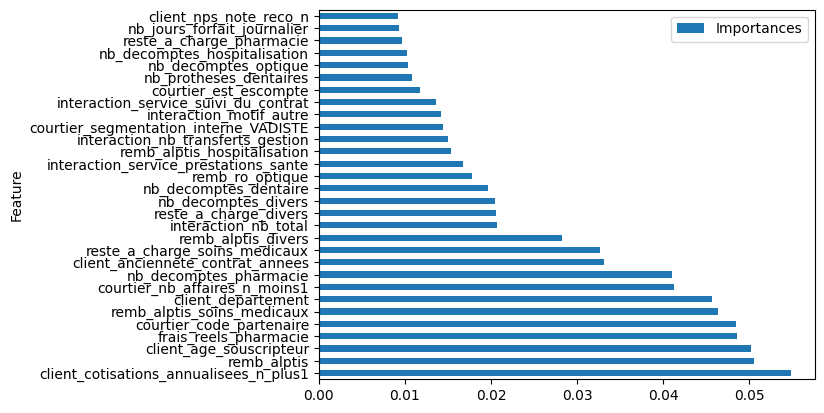

In [ ]:
#Let's visualise the feature importance based on this RandomForest
importances= rf.feature_importances_
features_name = X_train.columns
feature_importance_df= pd.DataFrame({"Feature":features_name, "Importances": importances}).sort_values(by="Importances", ascending=False)

#Visualiation top 30 features
feature_importance_df[:30].plot(kind="barh", x= "Feature", y="Importances")

As we expected, most of the important features are linked to the annual health consumption of the clients. 
The top three most important features concern:
- the annual premium
- the annual refund made by alptis (alptis_remb)
- the age of the client
This perfectly makes sens with the litterature and the typical explicative features in churn prediction model.

We also find important features about: 
- the localisation of the client (client_departement)
- the interraction with Alptis (nb_interaction) 
- broker (courtier_code_partenaire and courtier_est_escompte)

### Pattern among the brokers: PCA and Clustering

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


#Let's focus on the variables linked to the broker
broker_columns=[c for c in df_merged.columns if c.startswith("courtier")]
X_broker=df_merged[broker_columns]
X_broker=pd.get_dummies(data=X_broker, columns= ["courtier_reseau_courtage"])
print(f"Number of columns about the broker {len(X_broker.columns)}")
X_broker.columns

Number of columns about the broker 34


Index(['courtier_code_partenaire', 'courtier_anciennete_annees',
       'courtier_code_apporteur', 'courtier_est_escompte',
       'courtier_nb_affaires_n_moins1', 'courtier_nb_radiations_n_moins1',
       'courtier_nb_affaires_n_moins2', 'courtier_nb_radiations_n_moins2',
       'courtier_changement_dans_les_12_mois',
       'courtier_segmentation_interne_Alptis',
       'courtier_segmentation_interne_CMA',
       'courtier_segmentation_interne_Dilemme',
       'courtier_segmentation_interne_Filiale',
       'courtier_segmentation_interne_Groupements',
       'courtier_segmentation_interne_Inactif à relancer',
       'courtier_segmentation_interne_Miltis',
       'courtier_segmentation_interne_Non catégorisé',
       'courtier_segmentation_interne_Nouveau',
       'courtier_segmentation_interne_Opportuniste',
       'courtier_segmentation_interne_Partenariats',
       'courtier_segmentation_interne_Petit Producteur',
       'courtier_segmentation_interne_Potentiel',
       'courtier_s

In [ ]:

#Let's standardize the values (except the booleans)
X_broker_stand = StandardScaler().fit_transform(X_broker.select_dtypes(exclude= ["bool"]))

pca=PCA(n_components=4)
pca_broker=pca.fit_transform(X_broker_stand)
pca_broker_df = pd.DataFrame(data = pca_broker
             , columns = ['principal component 1', 'principal component 2', 'pca 3','pca 4'])
pca_broker_df

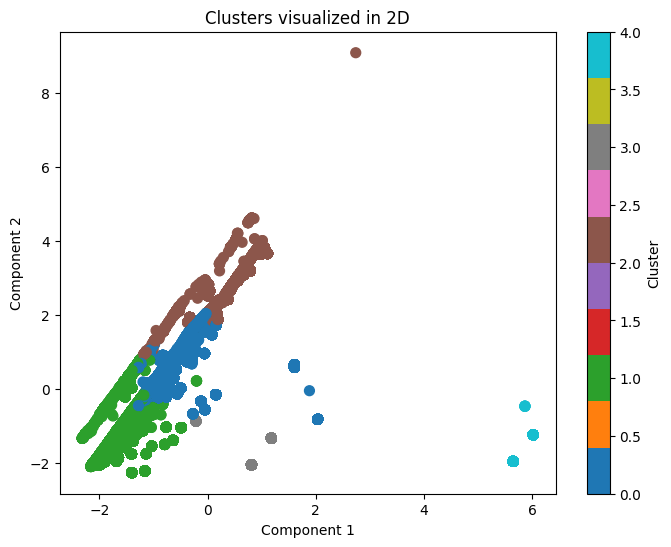

In [77]:

pipeline = Pipeline(steps=[
    ("pca", PCA(n_components=0.9)),   # keep 90% variance
    ("kmeans", KMeans(n_clusters=5, random_state=42))
])
labels = pipeline.fit_predict(X_broker_stand)

#Visualisation
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.pyplot as plt

# If sparse → TruncatedSVD is better
svd = TruncatedSVD(n_components=2, random_state=42)
X_broker_2d = svd.fit_transform(preprocessor.fit_transform(X_broker))  # preprocessor from previous pipeline
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(preprocessor.fit_transform(X_broker))

plt.figure(figsize=(8,6))
plt.scatter(X_broker_2d[:,0], X_broker_2d[:,1], c=labels, cmap="tab10", s=50)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Clusters visualized in 2D")
plt.colorbar(label="Cluster")
plt.show()
